C:\Users\Admin\AppData\Local\Temp\ipykernel_30396\36424730.py:107: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-12092.346914446727' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.df.iloc[i, self.df.columns.get_loc('breakout_energy')] = \


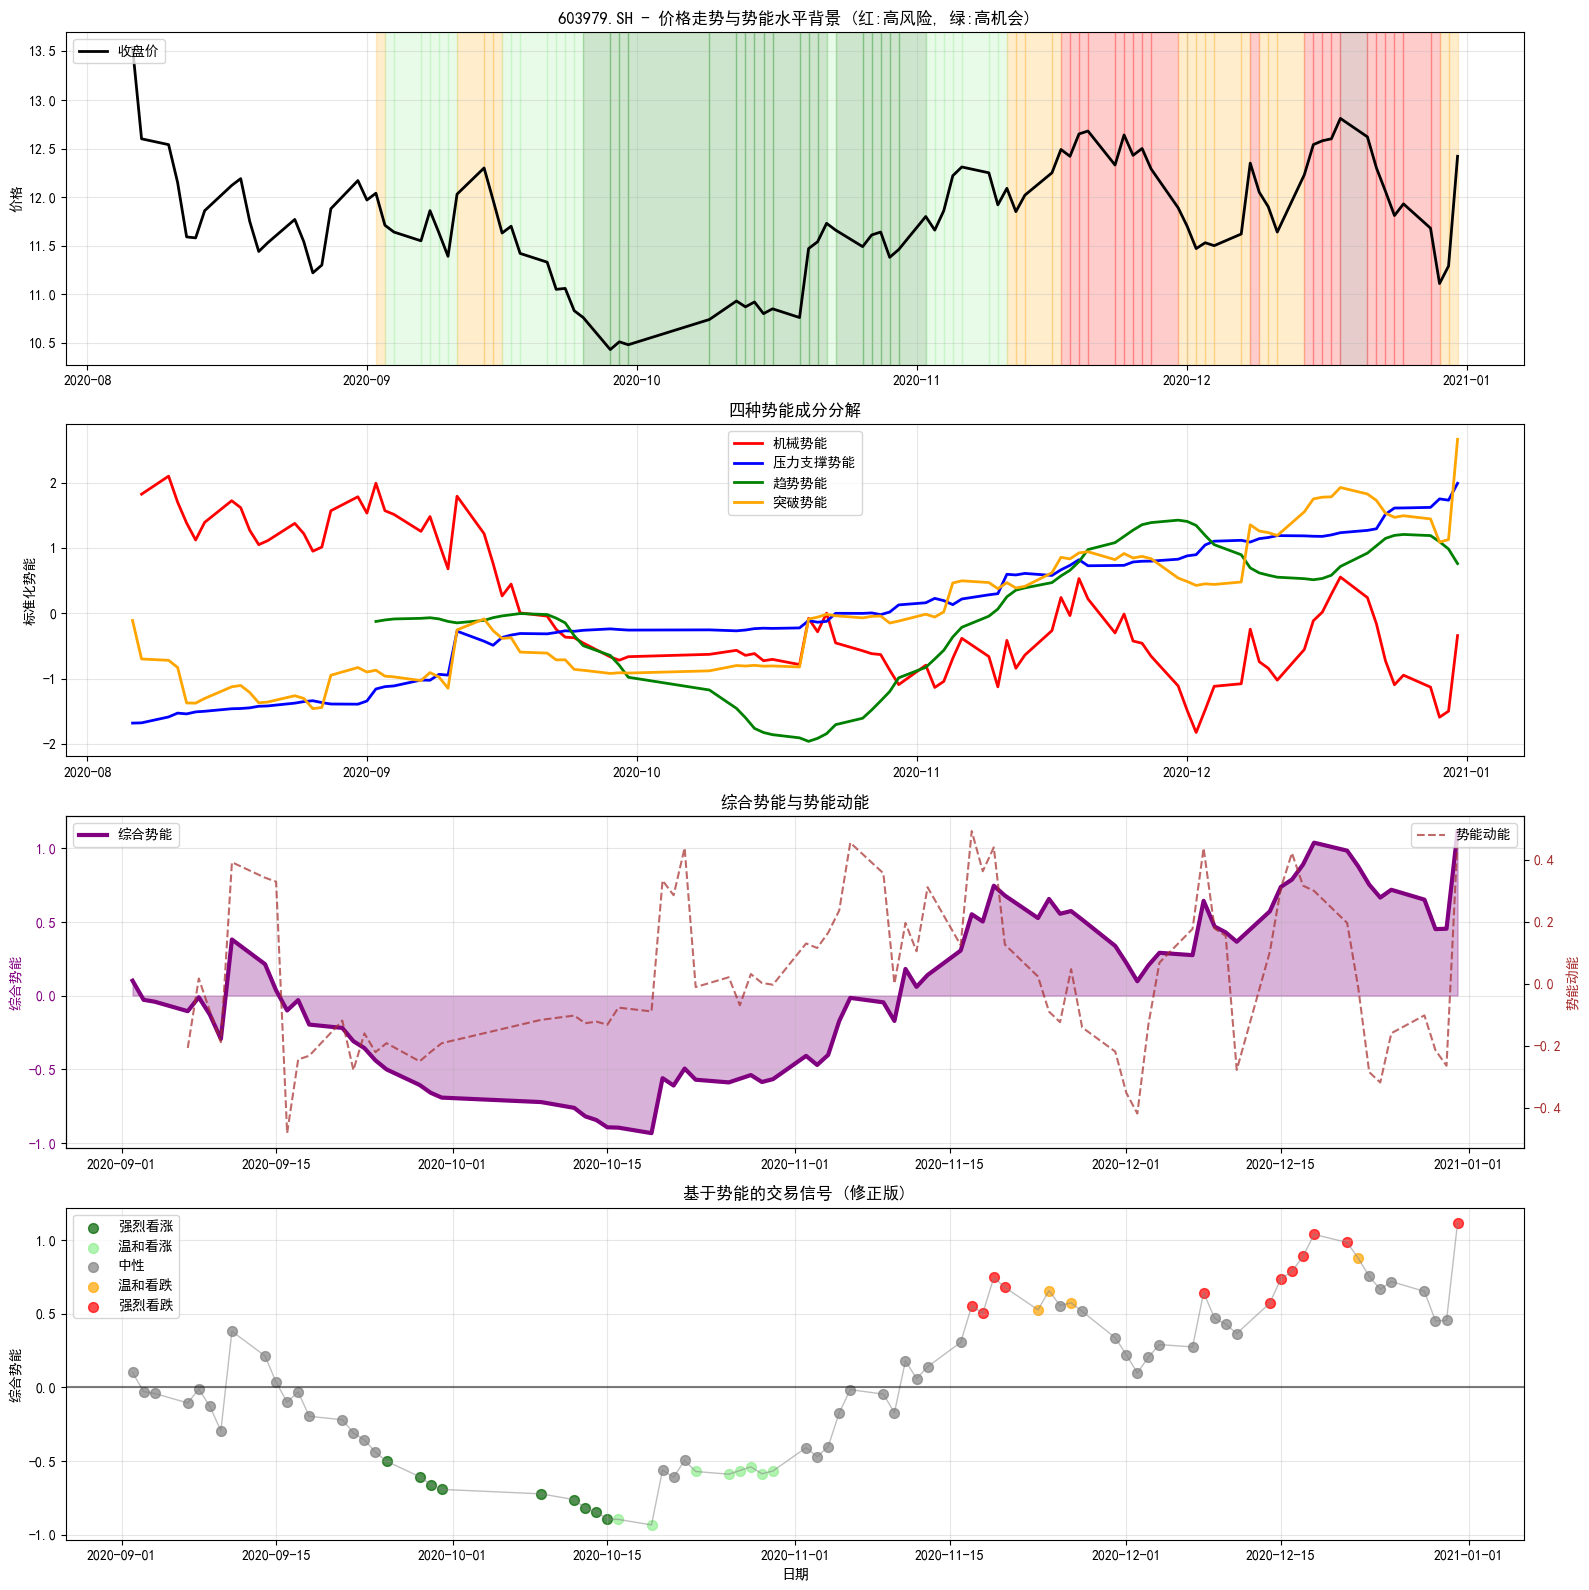

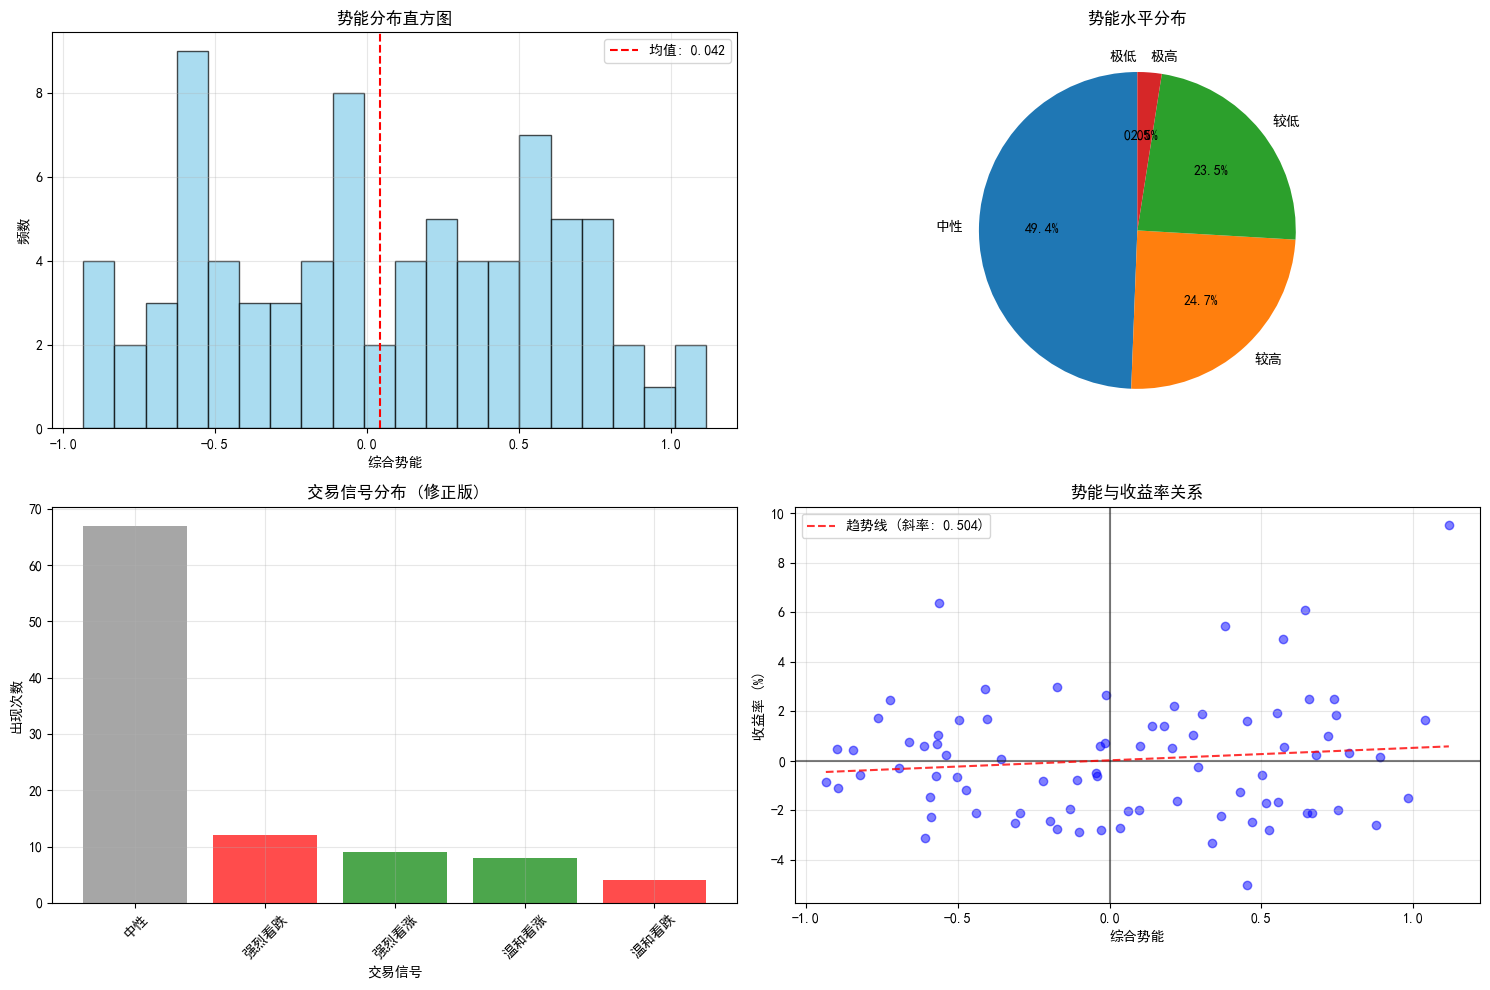

603979.SH 势能分析报告 (修正版)

1. 势能统计:
   综合势能均值: 0.0418
   综合势能标准差: 0.5483
   当前势能水平: 极高
   当前势能趋势: 加速上升

2. 交易信号分析 (修正逻辑):
   中性: 67次 (67.0%)
   强烈看跌: 12次 (12.0%)
   强烈看涨: 9次 (9.0%)
   温和看涨: 8次 (8.0%)
   温和看跌: 4次 (4.0%)

3. 势能成分贡献:
   机械势能: -0.3424
   压力支撑势能: 1.9887
   趋势势能: 0.7596
   突破势能: 2.6627

4. 当前建议 (修正版):
   🔴 强烈建议卖出 - 高势能区域，回调风险大

5. 势能预测效果:
   势能与收益率的相关系数: 0.1128
   ❌ 势能指标对收益率预测能力较弱

势能关键转折点分析 (修正逻辑)
发现 17 个势能峰值点 (高风险区域)
发现 18 个势能谷值点 (高机会区域)

最近势能峰值: 0.7183 (日期: 2020-12-25)
   🔴 高风险区域 - 考虑减仓或观望
最近势能谷值: 0.4513 (日期: 2020-12-29)
   🟢 高机会区域 - 考虑买入或加仓
势能峰值平均间隔: 6.8 天
势能谷值平均间隔: 6.6 天


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 数据加载
ts_code = "603979.SH"
analysis_dir = os.path.join('E:\stock\csv_version','analysis_results')
csv_path = Path(analysis_dir) / f"{ts_code}_analysis.csv"    
df = pd.read_csv(csv_path, index_col='trade_date', parse_dates=['trade_date'], nrows=100)
df = df[df.index < '2025-02-01'].tail(100)
df = df.sort_index()

class MomentumEnergyAnalyzer:
    def __init__(self, df):
        self.df = df.copy()
        self.calculate_technical_indicators()
        
    def calculate_technical_indicators(self):
        """计算技术指标用于势能评估"""
        # 基础价格变化
        self.df['price_change'] = self.df['close'].pct_change()
        self.df['log_return'] = np.log(self.df['close'] / self.df['close'].shift(1))
        
        # K线特征
        self.df['body_size'] = abs(self.df['close'] - self.df['open']) / self.df['open']
        self.df['total_range'] = (self.df['high'] - self.df['low']) / self.df['open']
        self.df['upper_shadow'] = (self.df['high'] - np.maximum(self.df['open'], self.df['close'])) / self.df['open']
        self.df['lower_shadow'] = (np.minimum(self.df['open'], self.df['close']) - self.df['low']) / self.df['open']
        
        # 价格位置特征
        self.df['price_position'] = (self.df['close'] - self.df['low']) / (self.df['high'] - self.df['low'])
        
        # 移动平均线
        self.df['ma5'] = self.df['close'].rolling(5).mean()
        self.df['ma20'] = self.df['close'].rolling(20).mean()
        
        # 成交量移动平均
        self.df['volume_ma5'] = self.df['volume'].rolling(5).mean()
        
        # 相对强弱
        self.df['relative_strength'] = (self.df['close'] - self.df['ma20']) / self.df['ma20']
    
    def calculate_potential_energy(self):
        """计算势能指标"""
        
        # 方法1: 动能势能模型
        # 动能 = 价格变化 × 成交量 (表示当前运动能量)
        self.df['kinetic_energy'] = self.df['log_return'] * self.df['volume']
        
        # 势能 = 价格位置 × 成交量 (表示潜在能量)
        # 在支撑位有向上势能，在阻力位有向下势能
        self.df['potential_energy'] = (self.df['price_position'] - 0.5) * self.df['volume'] * 2
        
        # 总机械能 = 动能 + 势能
        self.df['total_mechanical_energy'] = self.df['kinetic_energy'] + self.df['potential_energy']
        self.df['cumulative_mechanical_energy'] = self.df['total_mechanical_energy'].cumsum()
        
        # 方法2: 压力-支撑势能模型
        # 基于K线形态的压力支撑判断
        def calculate_pressure_support(row):
            # 上影线长表示压力大，下影线长表示支撑强
            pressure = row['upper_shadow'] * row['volume']
            support = row['lower_shadow'] * row['volume']
            
            # 实体方向加强压力支撑效果
            if row['close'] > row['open']:
                # 阳线：支撑有效，压力被突破
                net_effect = support - pressure * 0.5
            else:
                # 阴线：压力有效，支撑被突破
                net_effect = pressure - support * 0.5
                
            return net_effect
        
        self.df['pressure_support_energy'] = self.df.apply(calculate_pressure_support, axis=1)
        self.df['cumulative_pressure_support'] = self.df['pressure_support_energy'].cumsum()
        
        # 方法3: 趋势势能模型
        # 基于移动平均线的趋势强度
        self.df['trend_strength'] = (self.df['ma5'] - self.df['ma20']) / self.df['ma20'] * 100
        self.df['volume_trend_energy'] = self.df['trend_strength'] * self.df['volume'] / self.df['volume_ma5']
        self.df['cumulative_trend_energy'] = self.df['volume_trend_energy'].cumsum()
        
        # 方法4: 突破势能模型
        # 识别关键位置的突破能量
        self.df['breakout_energy'] = 0
        for i in range(1, len(self.df)):
            current = self.df.iloc[i]
            prev = self.df.iloc[i-1]
            
            # 突破前高
            if current['close'] > prev['high'] and current['volume'] > prev['volume']:
                self.df.iloc[i, self.df.columns.get_loc('breakout_energy')] = \
                    current['log_return'] * current['volume'] * 2
            # 跌破前低
            elif current['close'] < prev['low'] and current['volume'] > prev['volume']:
                self.df.iloc[i, self.df.columns.get_loc('breakout_energy')] = \
                    current['log_return'] * current['volume'] * 2
            # 普通情况
            else:
                self.df.iloc[i, self.df.columns.get_loc('breakout_energy')] = \
                    current['log_return'] * current['volume']
        
        self.df['cumulative_breakout_energy'] = self.df['breakout_energy'].cumsum()
        
        # 综合势能指标（加权组合）
        weights = {
            'mechanical': 0.3,
            'pressure_support': 0.25,
            'trend': 0.25,
            'breakout': 0.2
        }
        
        # 标准化各能量指标
        for col in ['cumulative_mechanical_energy', 'cumulative_pressure_support', 
                   'cumulative_trend_energy', 'cumulative_breakout_energy']:
            if self.df[col].std() > 0:
                self.df[f'normalized_{col}'] = (self.df[col] - self.df[col].mean()) / self.df[col].std()
            else:
                self.df[f'normalized_{col}'] = 0
        
        # 计算综合势能
        self.df['comprehensive_energy'] = (
            weights['mechanical'] * self.df['normalized_cumulative_mechanical_energy'] +
            weights['pressure_support'] * self.df['normalized_cumulative_pressure_support'] +
            weights['trend'] * self.df['normalized_cumulative_trend_energy'] +
            weights['breakout'] * self.df['normalized_cumulative_breakout_energy']
        )
        
        # 势能变化率（势能的动能）
        self.df['energy_momentum'] = self.df['comprehensive_energy'].diff(3)  # 3期变化
    
    def generate_signals(self):
        """基于势能生成交易信号 - 修正版"""
        # 势能水平信号
        self.df['energy_level'] = pd.cut(
            self.df['comprehensive_energy'], 
            bins=[-np.inf, -1, -0.5, 0.5, 1, np.inf],
            labels=['极低', '较低', '中性', '较高', '极高']
        )
        
        # 势能变化信号
        self.df['energy_trend'] = np.where(
            self.df['energy_momentum'] > 0.1, '加速上升',
            np.where(self.df['energy_momentum'] < -0.1, '加速下降', '平稳')
        )
        
        # 修正信号逻辑 - 看涨看跌反转
        conditions = [
            # 高势能 + 加速上升 → 强烈看跌（过热，可能反转）
            (self.df['energy_level'].isin(['极高', '较高'])) & (self.df['energy_trend'] == '加速上升'),
            # 低势能 + 加速下降 → 强烈看涨（超卖，可能反弹）
            (self.df['energy_level'].isin(['极低', '较低'])) & (self.df['energy_trend'] == '加速下降'),
            # 高势能 + 平稳 → 温和看跌
            (self.df['energy_level'].isin(['较高'])) & (self.df['energy_trend'] == '平稳'),
            # 低势能 + 平稳 → 温和看涨
            (self.df['energy_level'].isin(['较低'])) & (self.df['energy_trend'] == '平稳')
        ]
        choices = ['强烈看跌', '强烈看涨', '温和看跌', '温和看涨']  # 修正：看涨看跌反转
        self.df['trading_signal'] = np.select(conditions, choices, default='中性')
    
    def plot_energy_analysis(self):
        """绘制势能分析图表"""
        fig, axes = plt.subplots(4, 1, figsize=(16, 16))
        
        # 图1: 价格走势和势能水平
        ax1 = axes[0]
        # 价格
        ax1.plot(self.df.index, self.df['close'], label='收盘价', color='black', linewidth=2)
        ax1.set_ylabel('价格', color='black')
        ax1.tick_params(axis='y', labelcolor='black')
        
        # 势能水平背景色 - 修正颜色逻辑
        for i in range(len(self.df)):
            energy_val = self.df['comprehensive_energy'].iloc[i]
            if pd.isna(energy_val):
                continue
                
            # 修正：高势能用红色（风险），低势能用绿色（机会）
            if energy_val > 1:
                color = 'darkred'    # 极高势能 - 高风险
            elif energy_val > 0.5:
                color = 'red'        # 较高势能 - 风险
            elif energy_val > 0:
                color = 'orange'     # 中性偏正
            elif energy_val > -0.5:
                color = 'lightgreen' # 中性偏负
            elif energy_val > -1:
                color = 'green'      # 较低势能 - 机会
            else:
                color = 'darkgreen'  # 极低势能 - 高机会
                
            if i < len(self.df) - 1:
                ax1.axvspan(self.df.index[i], self.df.index[i+1], 
                           alpha=0.2, color=color)
        
        ax1.set_title(f'{ts_code} - 价格走势与势能水平背景 (红:高风险, 绿:高机会)')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)
        
        # 图2: 四种势能成分
        axes[1].plot(self.df.index, self.df['normalized_cumulative_mechanical_energy'], 
                    label='机械势能', color='red', linewidth=2)
        axes[1].plot(self.df.index, self.df['normalized_cumulative_pressure_support'], 
                    label='压力支撑势能', color='blue', linewidth=2)
        axes[1].plot(self.df.index, self.df['normalized_cumulative_trend_energy'], 
                    label='趋势势能', color='green', linewidth=2)
        axes[1].plot(self.df.index, self.df['normalized_cumulative_breakout_energy'], 
                    label='突破势能', color='orange', linewidth=2)
        axes[1].set_ylabel('标准化势能')
        axes[1].set_title('四种势能成分分解')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # 图3: 综合势能和动能
        ax3 = axes[2]
        # 综合势能
        ax3.plot(self.df.index, self.df['comprehensive_energy'], 
                label='综合势能', color='purple', linewidth=3)
        ax3.fill_between(self.df.index, self.df['comprehensive_energy'], 
                        alpha=0.3, color='purple')
        ax3.set_ylabel('综合势能', color='purple')
        ax3.tick_params(axis='y', labelcolor='purple')
        ax3.legend(loc='upper left')
        
        # 势能动能（变化率）
        ax3b = ax3.twinx()
        ax3b.plot(self.df.index, self.df['energy_momentum'], 
                 label='势能动能', color='brown', linestyle='--', alpha=0.7)
        ax3b.set_ylabel('势能动能', color='brown')
        ax3b.tick_params(axis='y', labelcolor='brown')
        ax3b.legend(loc='upper right')
        ax3.set_title('综合势能与势能动能')
        ax3.grid(True, alpha=0.3)
        
        # 图4: 交易信号 - 修正颜色
        axes[3].plot(self.df.index, self.df['comprehensive_energy'], 
                    color='gray', alpha=0.5, linewidth=1)
        
        # 根据信号着色 - 修正颜色逻辑
        signal_colors = {
            '强烈看涨': 'darkgreen',    # 看涨用绿色
            '温和看涨': 'lightgreen',   # 温和看涨用浅绿色
            '中性': 'gray',             # 中性用灰色
            '温和看跌': 'orange',       # 温和看跌用橙色
            '强烈看跌': 'red'           # 看跌用红色
        }
        
        for signal in signal_colors.keys():
            mask = self.df['trading_signal'] == signal
            if mask.any():
                axes[3].scatter(self.df.index[mask], self.df['comprehensive_energy'][mask],
                              color=signal_colors[signal], label=signal, s=50, alpha=0.7)
        
        axes[3].axhline(y=0, color='black', linestyle='-', alpha=0.5)
        axes[3].set_ylabel('综合势能')
        axes[3].set_xlabel('日期')
        axes[3].set_title('基于势能的交易信号 (修正版)')
        axes[3].legend()
        axes[3].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # 势能分布统计
        self.plot_energy_statistics()
    
    def plot_energy_statistics(self):
        """绘制势能统计图表"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # 势能分布直方图
        valid_energy = self.df['comprehensive_energy'].dropna()
        axes[0,0].hist(valid_energy, bins=20, 
                      color='skyblue', edgecolor='black', alpha=0.7)
        axes[0,0].axvline(valid_energy.mean(), 
                         color='red', linestyle='--', label=f'均值: {valid_energy.mean():.3f}')
        axes[0,0].set_xlabel('综合势能')
        axes[0,0].set_ylabel('频数')
        axes[0,0].set_title('势能分布直方图')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # 势能水平分布
        energy_level_counts = self.df['energy_level'].value_counts()
        axes[0,1].pie(energy_level_counts.values, labels=energy_level_counts.index, 
                     autopct='%1.1f%%', startangle=90)
        axes[0,1].set_title('势能水平分布')
        
        # 交易信号分布
        signal_counts = self.df['trading_signal'].value_counts()
        # 修正颜色：看涨用绿色，看跌用红色
        colors = ['green' if '涨' in x else 'red' if '跌' in x else 'gray' 
                 for x in signal_counts.index]
        axes[1,0].bar(signal_counts.index, signal_counts.values, color=colors, alpha=0.7)
        axes[1,0].set_xlabel('交易信号')
        axes[1,0].set_ylabel('出现次数')
        axes[1,0].set_title('交易信号分布 (修正版)')
        axes[1,0].tick_params(axis='x', rotation=45)
        axes[1,0].grid(True, alpha=0.3)
        
        # 势能与收益率关系
        temp_df = self.df[['comprehensive_energy', 'log_return']].dropna()
        if len(temp_df) > 0:
            axes[1,1].scatter(temp_df['comprehensive_energy'], temp_df['log_return']*100,
                             alpha=0.5, color='blue')
            axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
            axes[1,1].axvline(x=0, color='black', linestyle='-', alpha=0.5)
            axes[1,1].set_xlabel('综合势能')
            axes[1,1].set_ylabel('收益率 (%)')
            axes[1,1].set_title('势能与收益率关系')
            axes[1,1].grid(True, alpha=0.3)
            
            # 添加趋势线
            if len(temp_df) > 1:
                z = np.polyfit(temp_df['comprehensive_energy'], temp_df['log_return']*100, 1)
                p = np.poly1d(z)
                x_range = np.linspace(temp_df['comprehensive_energy'].min(), 
                                     temp_df['comprehensive_energy'].max(), 100)
                axes[1,1].plot(x_range, p(x_range), "r--", alpha=0.8, 
                              label=f'趋势线 (斜率: {z[0]:.3f})')
                axes[1,1].legend()
        else:
            axes[1,1].text(0.5, 0.5, '无有效数据', ha='center', va='center', 
                          transform=axes[1,1].transAxes)
            axes[1,1].set_title('势能与收益率关系 (无数据)')
        
        plt.tight_layout()
        plt.show()
    
    def print_analysis_report(self):
        """打印分析报告 - 修正版"""
        print("="*60)
        print(f"{ts_code} 势能分析报告 (修正版)")
        print("="*60)
        
        # 使用有效数据计算统计信息
        valid_energy = self.df['comprehensive_energy'].dropna()
        
        print(f"\n1. 势能统计:")
        print(f"   综合势能均值: {valid_energy.mean():.4f}")
        print(f"   综合势能标准差: {valid_energy.std():.4f}")
        if len(valid_energy) > 0:
            print(f"   当前势能水平: {self.df['energy_level'].iloc[-1]}")
            print(f"   当前势能趋势: {self.df['energy_trend'].iloc[-1]}")
        else:
            print(f"   当前势能水平: 无有效数据")
            print(f"   当前势能趋势: 无有效数据")
        
        print(f"\n2. 交易信号分析 (修正逻辑):")
        signal_summary = self.df['trading_signal'].value_counts()
        for signal, count in signal_summary.items():
            print(f"   {signal}: {count}次 ({count/len(self.df)*100:.1f}%)")
        
        print(f"\n3. 势能成分贡献:")
        components = {
            '机械势能': self.df['normalized_cumulative_mechanical_energy'].iloc[-1] if len(self.df) > 0 else 0,
            '压力支撑势能': self.df['normalized_cumulative_pressure_support'].iloc[-1] if len(self.df) > 0 else 0,
            '趋势势能': self.df['normalized_cumulative_trend_energy'].iloc[-1] if len(self.df) > 0 else 0,
            '突破势能': self.df['normalized_cumulative_breakout_energy'].iloc[-1] if len(self.df) > 0 else 0
        }
        for name, value in components.items():
            print(f"   {name}: {value:.4f}")
        
        print(f"\n4. 当前建议 (修正版):")
        if len(self.df) > 0:
            current_signal = self.df['trading_signal'].iloc[-1]
            # 修正建议逻辑
            if '强烈看涨' in current_signal:
                print("   🟢 强烈建议买入 - 低势能区域，反弹机会大")
            elif '温和看涨' in current_signal:
                print("   🟡 可考虑买入 - 较低势能区域，有上涨潜力")
            elif '强烈看跌' in current_signal:
                print("   🔴 强烈建议卖出 - 高势能区域，回调风险大")
            elif '温和看跌' in current_signal:
                print("   🟠 可考虑减仓 - 较高势能区域，注意风险")
            else:
                print("   ⚪ 中性建议 - 等待明确信号")
        else:
            print("   ⚪ 无有效数据")
        
        # 势能与收益率的相关系数
        temp_df = self.df[['comprehensive_energy', 'log_return']].dropna()
        if len(temp_df) > 1:
            corr = temp_df['comprehensive_energy'].corr(temp_df['log_return'])
            print(f"\n5. 势能预测效果:")
            print(f"   势能与收益率的相关系数: {corr:.4f}")
            # 修正解释逻辑
            if corr < -0.2:
                print("   ✅ 势能指标对收益率有较好的反向预测能力")
            elif corr < -0.1:
                print("   ⚠️  势能指标对收益率有一定反向预测能力")
            elif corr > 0.2:
                print("   ⚠️  势能指标与收益率正相关，需要重新评估模型")
            else:
                print("   ❌ 势能指标对收益率预测能力较弱")
        else:
            print(f"\n5. 势能预测效果: 无足够数据计算相关性")

# 运行分析
analyzer = MomentumEnergyAnalyzer(df)
analyzer.calculate_potential_energy()
analyzer.generate_signals()
analyzer.plot_energy_analysis()
analyzer.print_analysis_report()

# 额外的势能转折点分析
print("\n" + "="*60)
print("势能关键转折点分析 (修正逻辑)")
print("="*60)

# 寻找势能极值点
energy = analyzer.df['comprehensive_energy'].dropna()
if len(energy) > 2:
    local_max = (energy.shift(1) < energy) & (energy.shift(-1) < energy)
    local_min = (energy.shift(1) > energy) & (energy.shift(-1) > energy)

    max_points = energy[local_max]
    min_points = energy[local_min]

    print(f"发现 {len(max_points)} 个势能峰值点 (高风险区域)")
    print(f"发现 {len(min_points)} 个势能谷值点 (高机会区域)")

    if len(max_points) > 0:
        print(f"\n最近势能峰值: {max_points.iloc[-1]:.4f} (日期: {max_points.index[-1].strftime('%Y-%m-%d')})")
        print("   🔴 高风险区域 - 考虑减仓或观望")
    if len(min_points) > 0:
        print(f"最近势能谷值: {min_points.iloc[-1]:.4f} (日期: {min_points.index[-1].strftime('%Y-%m-%d')})")
        print("   🟢 高机会区域 - 考虑买入或加仓")

    # 势能周期分析
    if len(max_points) >= 2 and len(min_points) >= 2:
        max_dates = max_points.index
        min_dates = min_points.index
        
        if len(max_dates) >= 2:
            max_periods = [(max_dates[i+1] - max_dates[i]).days for i in range(len(max_dates)-1)]
            avg_max_period = np.mean(max_periods)
            print(f"势能峰值平均间隔: {avg_max_period:.1f} 天")
        
        if len(min_dates) >= 2:
            min_periods = [(min_dates[i+1] - min_dates[i]).days for i in range(len(min_dates)-1)]
            avg_min_period = np.mean(min_periods)
            print(f"势能谷值平均间隔: {avg_min_period:.1f} 天")
else:
    print("数据不足，无法进行势能转折点分析")